In [26]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl
import seaborn as sns
import h5py
import time
import scipy.sparse as sp
import yaml
import gc
from matplotlib import gridspec
from pandas.api.types import CategoricalDtype

import rmm
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

import cuml
from cuml.decomposition import PCA
from cuml.manifold import TSNE
from cuml.manifold import UMAP

import psutil
import torch
from datetime import datetime

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

sc.settings.verbosity = 3

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
start = time.perf_counter()

fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/processed/sample_1_adata.h5ad"
adata = sc.read_h5ad(fpath)
adata.obsm['X_umap'] = adata.obsm['X_umap_X_scANVI'].copy()

adata.obs_names_make_unique()
adata.var_names_make_unique()

sc.logging.print_memory_usage() # Log memory at the end

print(f"Total time: {time.perf_counter() - start:.2f} seconds")

adata # Return/output adata

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Memory usage: current 48.82 GB, difference +48.82 GB
Total time: 39.37 seconds


AnnData object with n_obs × n_vars = 1125041 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette

# Filter basename

In [3]:
%%time
keep = [
    'fibroblasts',
    'endothelial_cells',
    'hematopoietic_progenitors',
    'hsc',
]

adata = adata[adata.obs['basename'].isin(keep), :].copy()
adata

CPU times: user 7.21 s, sys: 17.9 s, total: 25.1 s
Wall time: 25.2 s


AnnData object with n_obs × n_vars = 509808 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette'

In [4]:
keep = [
    'CD34-positive, CD38-negative hematopoietic stem cell',
    'blood vessel endothelial cell',
    'cord blood hematopoietic stem cell',
    'embryonic fibroblast',
    'endothelial cell',
    'erythroid progenitor cell',
    'hematopoietic multipotent progenitor cell',
    'hematopoietic precursor cell',
    'hematopoietic stem cell',
    'megakaryocyte progenitor cell',
    'skin fibroblast',
    'vein endothelial cell',
    'fibroblast',
]

adata = adata[adata.obs['cell_type'].isin(keep), :].copy()

clean_labels = {
    'CD34-positive, CD38-negative hematopoietic stem cell': 'CD34+ CD38− HSC',
    'blood vessel endothelial cell': 'vascular endothelial cell',
    'cord blood hematopoietic stem cell': 'cord blood HSC',
    'embryonic fibroblast': 'embryonic fibroblast',
    'endothelial cell': 'endothelial cell',
    'fibroblast' : 'fibroblast',
    'erythroid progenitor cell': 'erythroid progenitor',
    'hematopoietic multipotent progenitor cell': 'multipotent progenitor (MPP)',
    'hematopoietic precursor cell': 'hematopoietic precursor',
    'hematopoietic stem cell': 'hematopoietic stem cell (HSC)',
    'megakaryocyte progenitor cell': 'megakaryocyte progenitor',
    'skin fibroblast': 'dermal fibroblast',
    'vein endothelial cell': 'venous endothelial cell',
}

adata.obs['cell_type_label'] = adata.obs['cell_type'].map(clean_labels)
print(adata.obs['cell_type_label'].value_counts().to_string())

cell_type_label
fibroblast                       111975
endothelial cell                  42113
vascular endothelial cell         31409
erythroid progenitor              23229
multipotent progenitor (MPP)      23176
venous endothelial cell           19631
dermal fibroblast                 17272
hematopoietic stem cell (HSC)     13464
cord blood HSC                     9056
hematopoietic precursor            4253
embryonic fibroblast               1709
megakaryocyte progenitor            904
CD34+ CD38− HSC                      74


In [5]:
# break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Sample

In [6]:
fraction = 0.25
adata = adata.copy()
adata = sc.pp.subsample(adata, fraction=fraction, copy=True)

sc.pp.filter_cells(adata, min_counts=300)
sc.pp.filter_genes(adata, min_counts=100)

print(f"Filtered: {adata.shape=}")
adata

filtered out 27 cells that have less than 300 counts
filtered out 29007 genes that are detected in less than 100 counts
Filtered: adata.shape=(74539, 23157)


AnnData object with n_obs × n_vars = 74539 × 23157
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden', 'cell_type_label'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 

# PAGA

[2025-05-14 14:55:51.610] [CUML] [debug] n_neighbors=250
[2025-05-14 14:55:51.610] [CUML] [debug] Calling knn graph run
[2025-05-14 14:55:51.610] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-14 14:55:51.867] [CUML] [debug] Done. Calling remove zeros
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:22)
--> added 'pos', the PAGA positions (adata.uns['paga'])


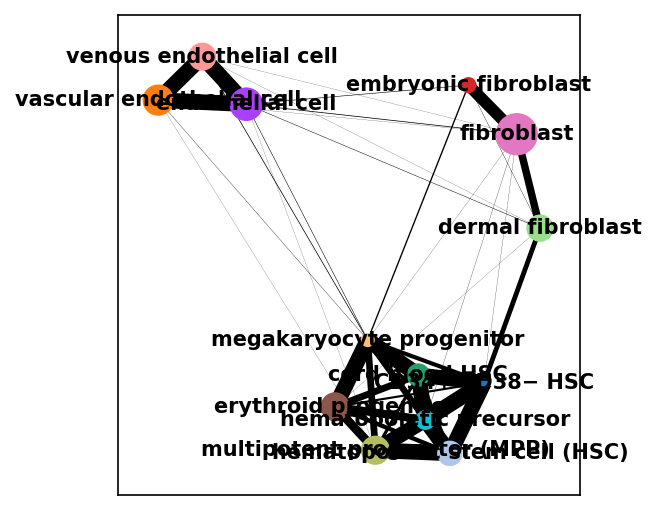

In [11]:
rsc.get.anndata_to_GPU(adata) # move to GPU
rsc.pp.neighbors(adata, n_neighbors=250, use_rep='X_scANVI')

sc.tl.paga(adata, groups='cell_type_label')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4
sc.pl.paga(adata)

[2025-05-14 15:04:02.026] [CUML] [debug] n_neighbors=1500
[2025-05-14 15:04:02.026] [CUML] [debug] Calling knn graph run
[2025-05-14 15:04:02.026] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-14 15:04:09.309] [CUML] [debug] Done. Calling remove zeros


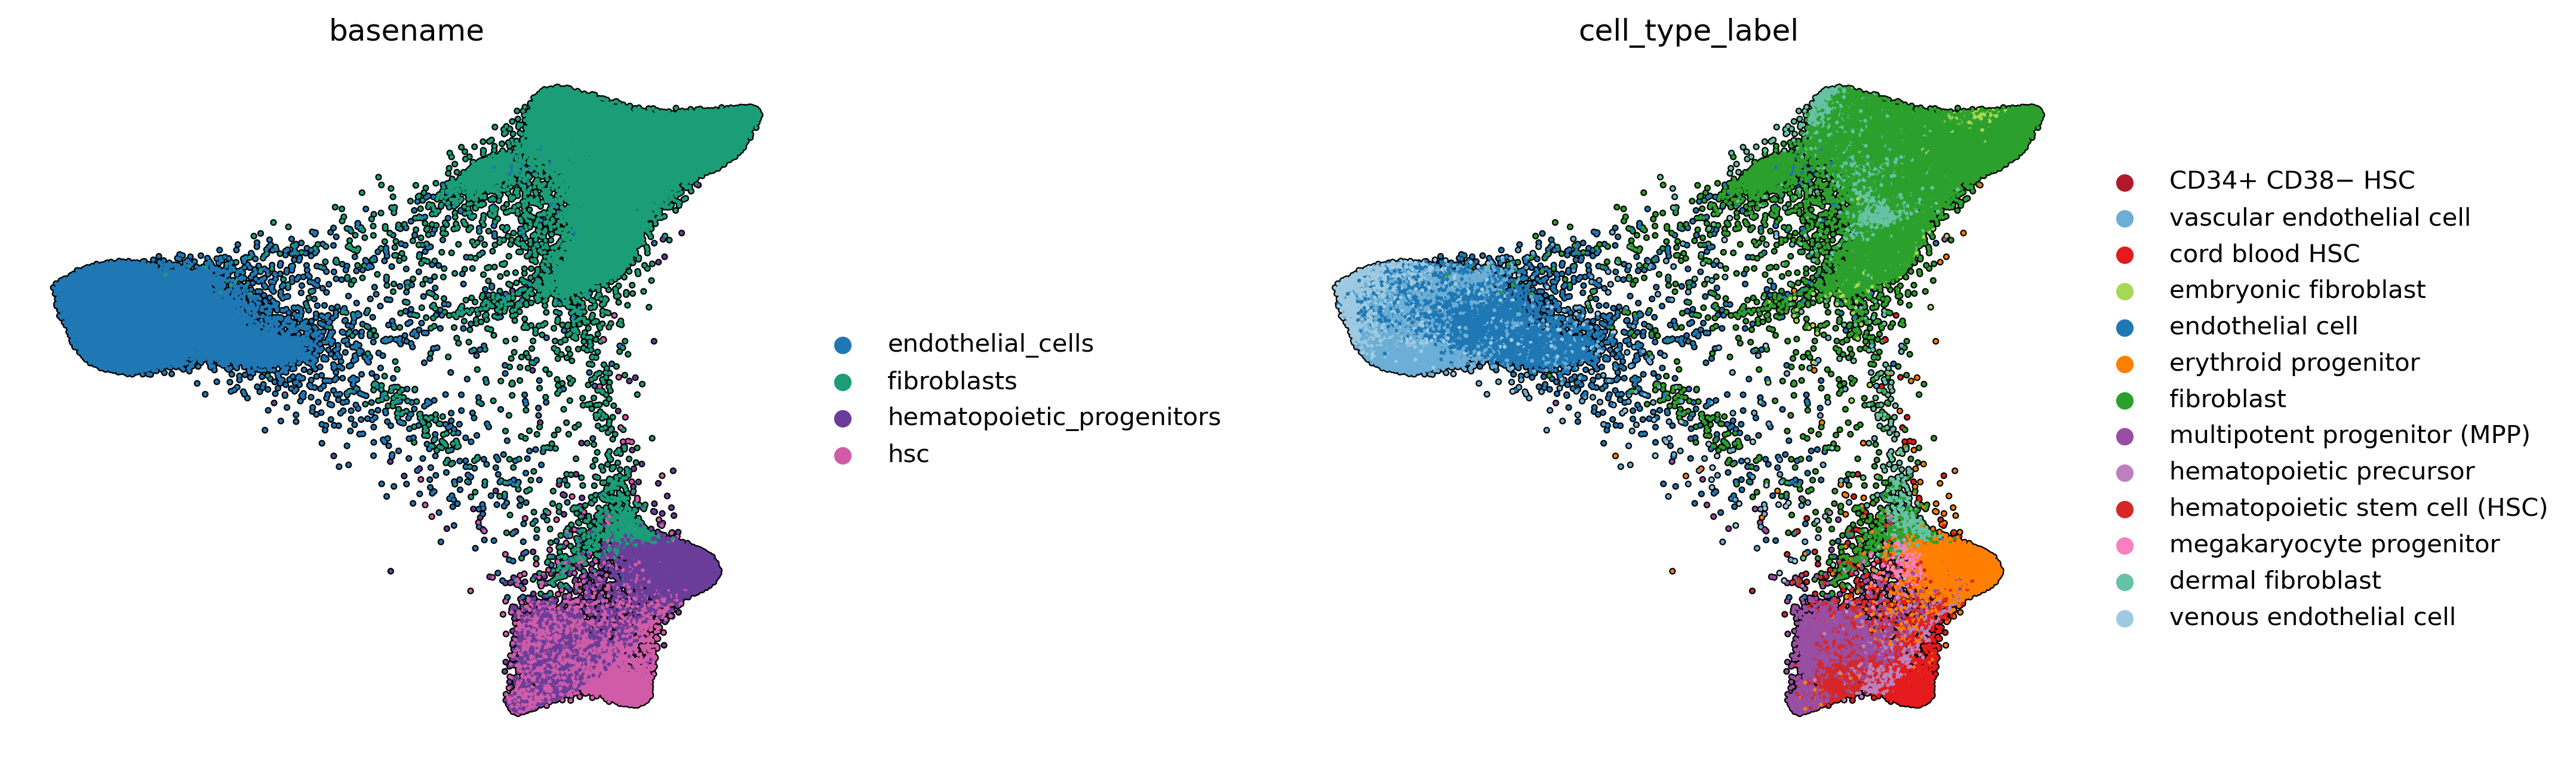

In [22]:
rsc.pp.neighbors(adata, n_neighbors=1500, use_rep='X_scANVI')
rsc.tl.draw_graph(adata, init_pos='paga')

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 5

sc.pl.draw_graph(
    adata, 
    color=["basename", "cell_type_label"],
    size=10,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

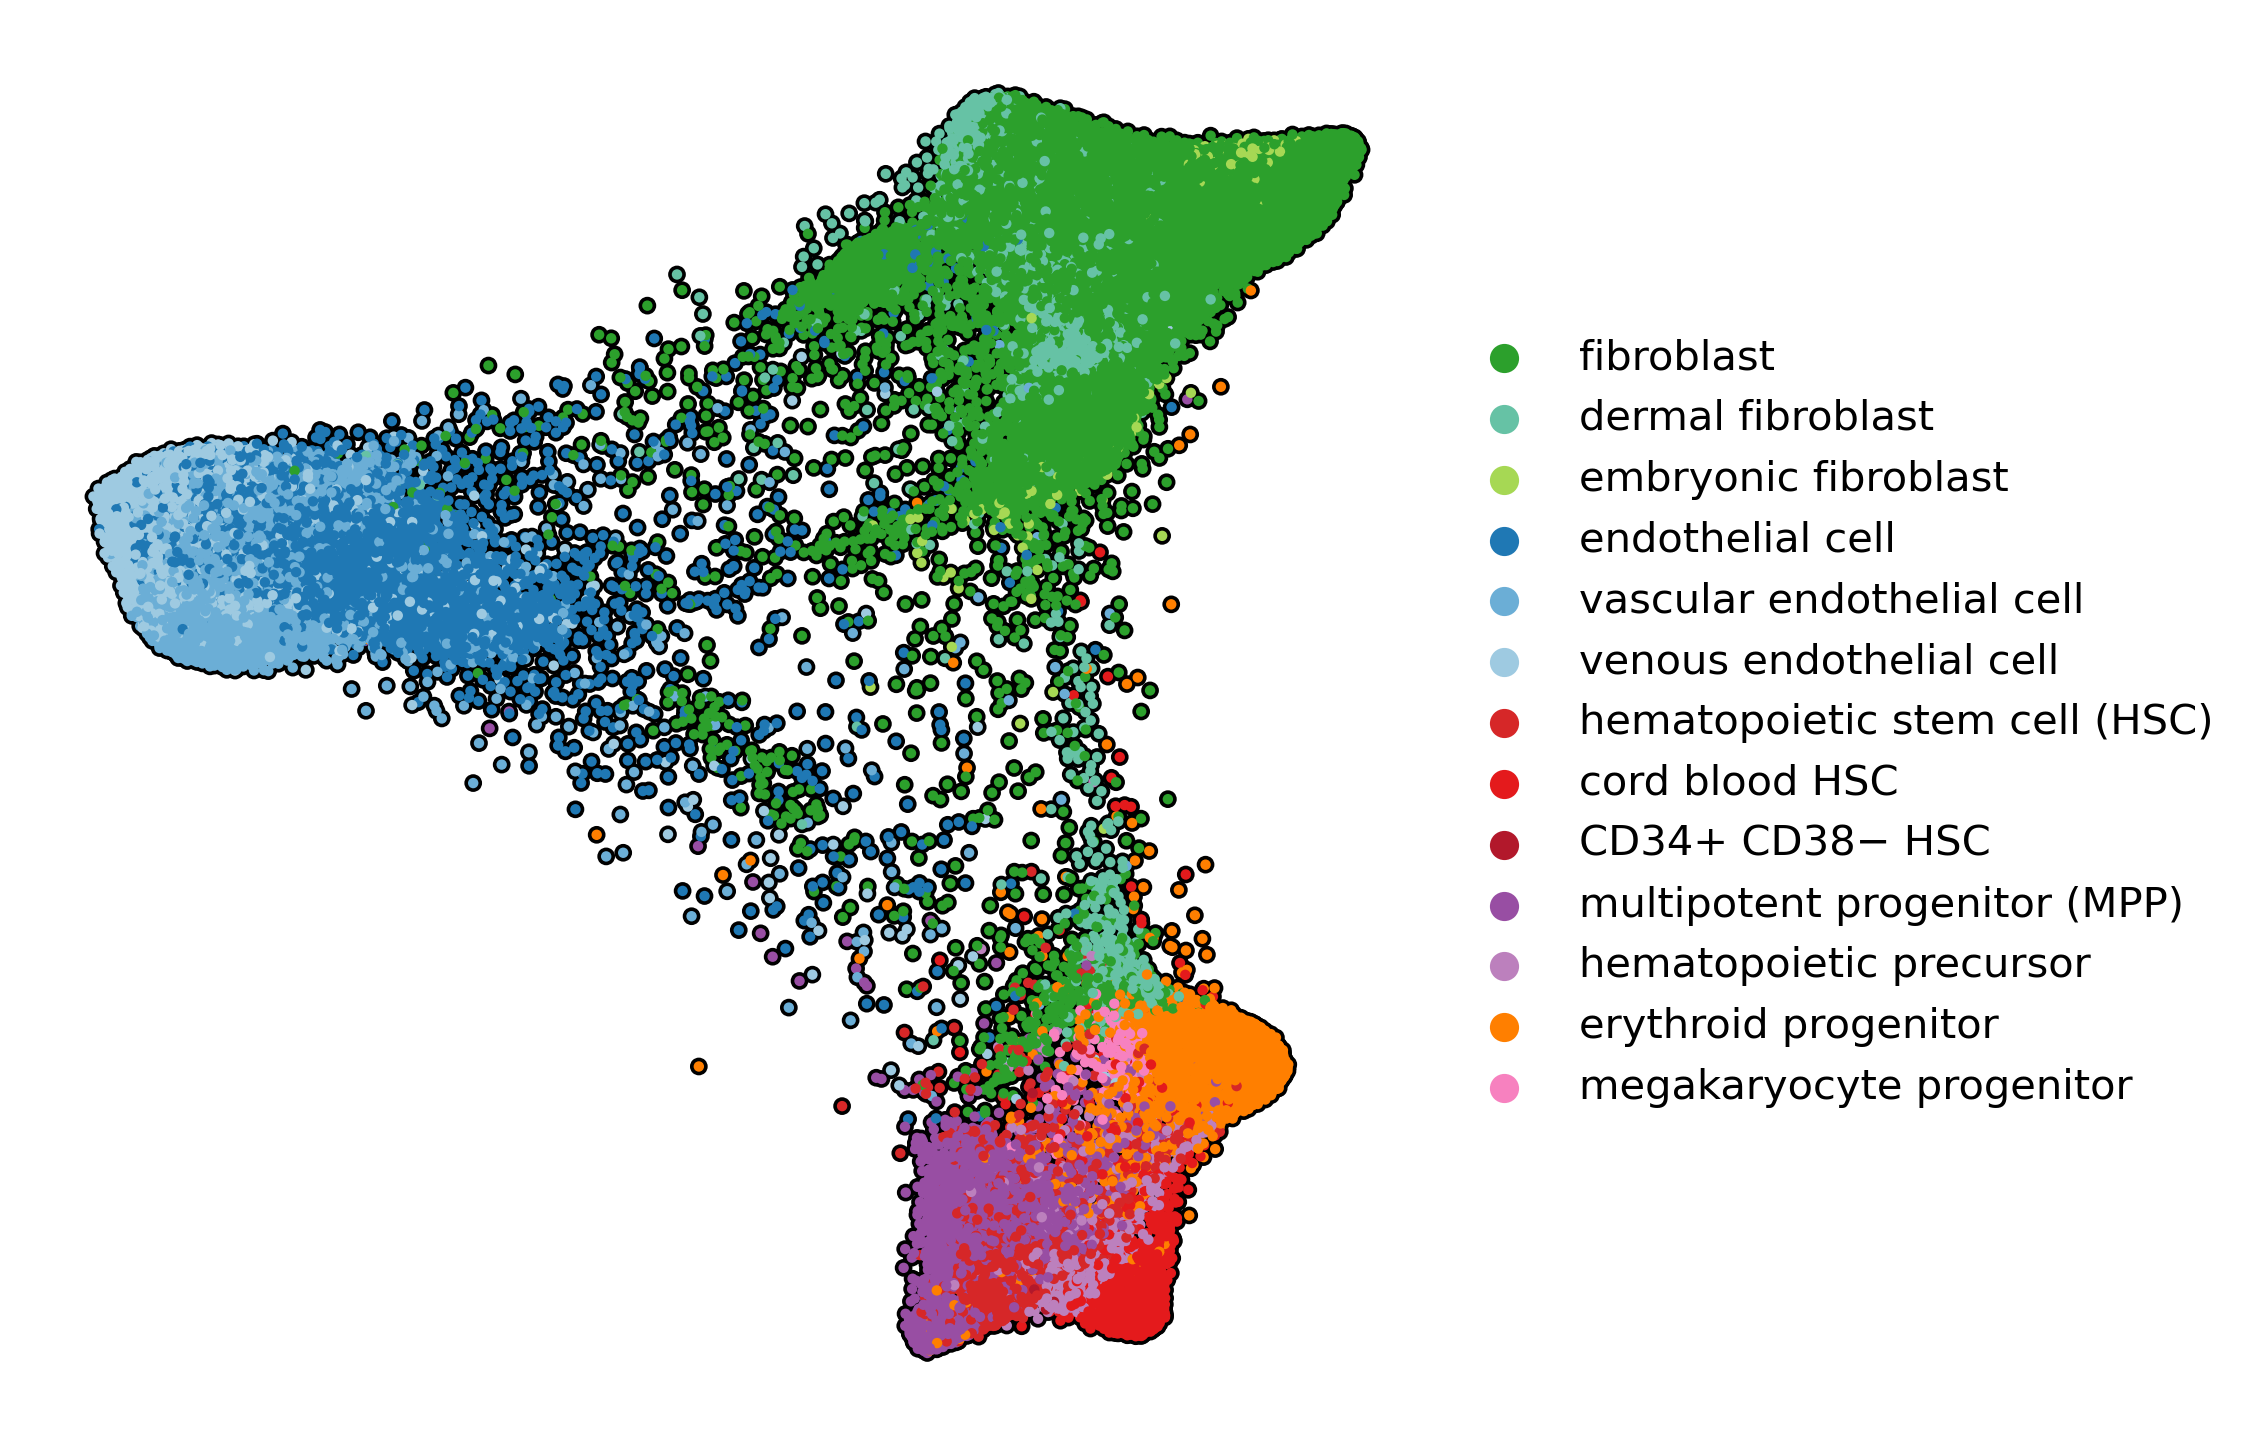

In [28]:
palette = {
    # Fibroblasts (green)
    'fibroblast': '#2ca02c',
    'dermal fibroblast': '#66c2a5',
    'embryonic fibroblast': '#a6d854',

    # Endothelial (blue)
    'endothelial cell': '#1f78b4',
    'vascular endothelial cell': '#6baed6',
    'venous endothelial cell': '#9ecae1',

    # HSCs and progenitors (red/purple)
    'hematopoietic stem cell (HSC)': '#d62728',
    'cord blood HSC': '#e41a1c',
    'CD34+ CD38− HSC': '#b2182b',
    'multipotent progenitor (MPP)': '#984ea3',
    'hematopoietic precursor': '#bc80bd',
    'erythroid progenitor': '#ff7f00',
    'megakaryocyte progenitor': '#f781bf',
}


# Define the desired order
cell_type_order = list(palette.keys())

# Enforce category order on the string column
adata.obs['cell_type_label'] = adata.obs['cell_type_label'].astype(
    CategoricalDtype(categories=cell_type_order, ordered=True)
)


plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 6
sc.pl.draw_graph(
    adata, 
    color=["cell_type_label"],
    size=25,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    title="",
    frameon=False,
    palette=palette,
)

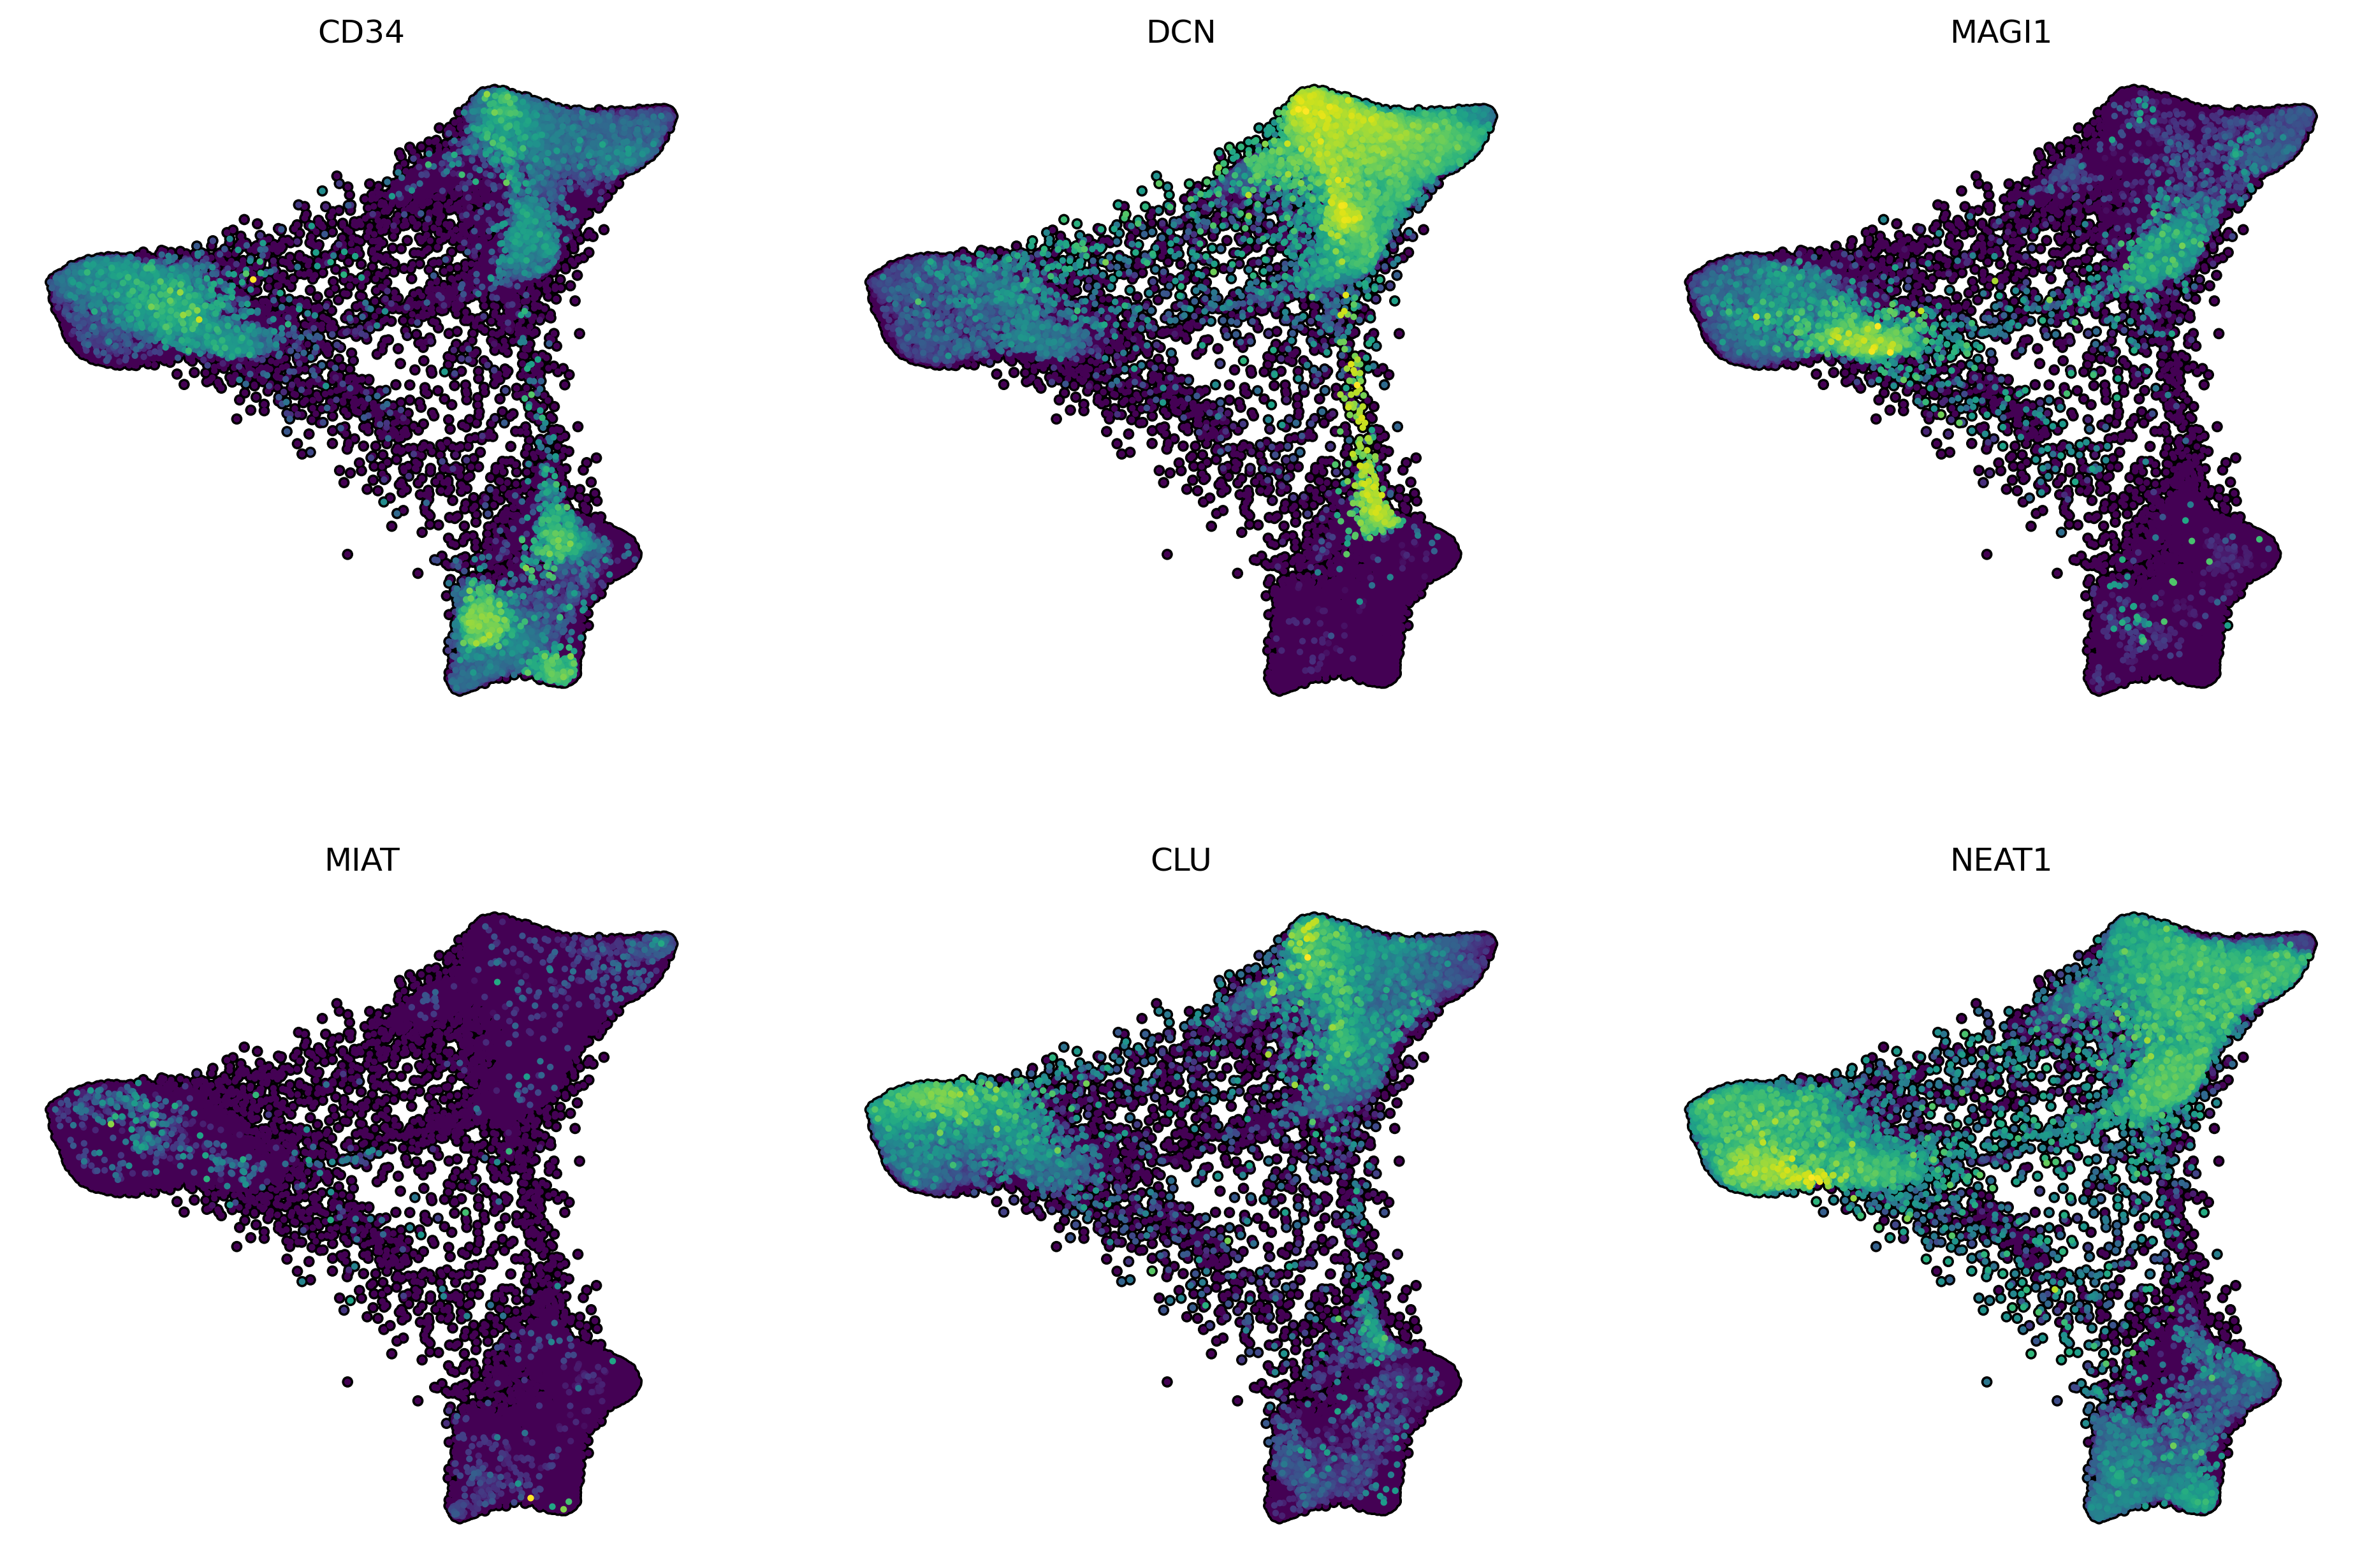

In [25]:
rsc.get.anndata_to_CPU(adata) # move to GPU

colors = [
    'CD34', 
    'DCN',
    'MAGI1', 
    'MIAT',
    'CLU',
    'NEAT1',
]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.25, 4.75

sc.pl.draw_graph(
    adata, 
    color=colors,
    size=25,
    ncols=3,
    alpha=1,
    colorbar_loc=None,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
)

# Load DEGs

In [45]:
# load tf list
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
print(f"{len(tf_list)=}")
tf_list[:10]

len(tf_list)=1892


['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

In [41]:
%%time
pvals_adj = 0.05
logfoldchanges = 1.0
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/sample_1_adata_cell_type_deg.parquet"

df = pd.read_parquet(fpath)
print(f"Raw data shape: {df.shape=}")

#filter 
df = df[df['group'].isin(keep)].copy()
df = df[df['pvals_adj'] < pvals_adj]
df = df[df['logfoldchanges'] > logfoldchanges]
df = df[~df['names'].str.startswith('ENSG')]
df = df.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])
df = df.reset_index(drop=True)

df['cell_type_label'] = df['group'].map(clean_labels)

print(f"Filtered data shape: {df.shape=}")

print(df.head().to_string())

Raw data shape: df.shape=(6103188, 8)
Filtered data shape: df.shape=(18009, 9)
                           group     names      scores  logfoldchanges  pvals  pvals_adj  pct_nz_group  pct_nz_reference            cell_type_label
0  blood vessel endothelial cell    TM4SF1  246.206024        5.773219    0.0        0.0      0.895348          0.180733  vascular endothelial cell
1  blood vessel endothelial cell    CYP1A1   99.296295        5.631924    0.0        0.0      0.339266          0.012280  vascular endothelial cell
2  blood vessel endothelial cell     HOXB9   60.872574        5.496808    0.0        0.0      0.207488          0.006826  vascular endothelial cell
3  blood vessel endothelial cell  C11orf91   40.390064        5.365011    0.0        0.0      0.137477          0.004105  vascular endothelial cell
4  blood vessel endothelial cell      SELE  114.410828        5.013944    0.0        0.0      0.403610          0.028154  vascular endothelial cell
CPU times: user 996 ms, sys: 264 

In [56]:
top_n = 10
latex_rows = []

groups = df['group'].unique()

for group in groups:
    sub = df[df['group'] == group].copy()
    cell_type = sub['cell_type_label'].iloc[0]
    top_genes = sub.nlargest(top_n, 'scores')

    for _, row in top_genes.iterrows():
        latex_rows.append({
            'Cell Type': cell_type,
            'Gene': row['names'],
            'logFC': f"{row['logfoldchanges']:.2f}",
            'Pct in Group': f"{row['pct_nz_group']:.2f}",
            'Pct in Ref': f"{row['pct_nz_reference']:.2f}"
        })

# Create DataFrame and output LaTeX
latex_df = pd.DataFrame(latex_rows)

latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    longtable=True,
    caption="Top 10 differentially expressed genes (DEGs) in fibroblast, endothelial, and hematopoietic populations.",
    label="tab:degs_fibro_endothelial_hematopoietic",
    column_format="llccc"
)

print(latex_table)

with open("../../results/degs_fibro_endothelial_hematopoietic.tex", "w") as f:
    f.write(latex_table)

\begin{longtable}{llccc}
\caption{Top 10 differentially expressed genes (DEGs) in fibroblast, endothelial, and hematopoietic populations.} \label{tab:degs_fibro_endothelial_hematopoietic} \\
\toprule
Cell Type & Gene & logFC & Pct in Group & Pct in Ref \\
\midrule
\endfirsthead
\caption[]{Top 10 differentially expressed genes (DEGs) in fibroblast, endothelial, and hematopoietic populations.} \\
\toprule
Cell Type & Gene & logFC & Pct in Group & Pct in Ref \\
\midrule
\endhead
\midrule
\multicolumn{5}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
vascular endothelial cell & TM4SF1 & 5.77 & 0.90 & 0.18 \\
vascular endothelial cell & MT2A & 4.17 & 0.91 & 0.44 \\
vascular endothelial cell & CD59 & 3.56 & 0.84 & 0.34 \\
vascular endothelial cell & SOD2 & 3.95 & 0.83 & 0.35 \\
vascular endothelial cell & UBC & 2.14 & 0.94 & 0.74 \\
vascular endothelial cell & EIF1 & 1.73 & 0.96 & 0.80 \\
vascular endothelial cell & NFKBIA & 2.83 & 0.88 & 0.53 \\
vascular endothelia

In [57]:
top_n = 10
latex_rows = []

groups = df['group'].unique()

for group in groups:
    sub = df[df['group'] == group].copy()
    sub = sub[sub['names'].isin(tf_list)]
    cell_type = sub['cell_type_label'].iloc[0]
    top_genes = sub.nlargest(top_n, 'scores')

    for _, row in top_genes.iterrows():
        latex_rows.append({
            'Cell Type': cell_type,
            'Gene': row['names'],
            'logFC': f"{row['logfoldchanges']:.2f}",
            'Pct in Group': f"{row['pct_nz_group']:.2f}",
            'Pct in Ref': f"{row['pct_nz_reference']:.2f}"
        })

# Create DataFrame and output LaTeX
latex_df = pd.DataFrame(latex_rows)

latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    longtable=True,
    caption="Top 10 differentially expressed TFs in fibroblast, endothelial, and hematopoietic populations.",
    label="tab:degs_fibro_endothelial_hematopoietic_TF",
    column_format="llccc"
)

print(latex_table)

with open("../../results/degs_fibro_endothelial_hematopoietic_TF.tex", "w") as f:
    f.write(latex_table)

\begin{longtable}{llccc}
\caption{Top 10 differentially expressed TFs in fibroblast, endothelial, and hematopoietic populations.} \label{tab:degs_fibro_endothelial_hematopoietic_TF} \\
\toprule
Cell Type & Gene & logFC & Pct in Group & Pct in Ref \\
\midrule
\endfirsthead
\caption[]{Top 10 differentially expressed TFs in fibroblast, endothelial, and hematopoietic populations.} \\
\toprule
Cell Type & Gene & logFC & Pct in Group & Pct in Ref \\
\midrule
\endhead
\midrule
\multicolumn{5}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
vascular endothelial cell & CD59 & 3.56 & 0.84 & 0.34 \\
vascular endothelial cell & JUND & 2.67 & 0.88 & 0.49 \\
vascular endothelial cell & ETS2 & 2.78 & 0.71 & 0.27 \\
vascular endothelial cell & MAFF & 2.91 & 0.65 & 0.19 \\
vascular endothelial cell & TCF4 & 2.07 & 0.79 & 0.40 \\
vascular endothelial cell & ATF3 & 2.70 & 0.62 & 0.21 \\
vascular endothelial cell & KLF6 & 1.87 & 0.80 & 0.53 \\
vascular endothelial cell & ETS1 & 2.